In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [6]:
df = pd.read_csv("../data/raw/data.csv")

df.head()

,Timestamp,Age,Gender,State,City,City_Tier,Marital_Status,Financial_Status,"Say for example , a similar product with similar features is being sold at half the price by an unknown seller as compared to a branded product. Would you purchase that product? or Simply Do you prefer cost over brands?",Product_Category,Decision_Time,"On a scale of 1 to 5 , how often do you shop in the selected product category monthly?",Avg_Spend
0,2021-06-10 22:41:22,21,Male,Uttar Pradesh,Lucknow,Tier 2,Not Married,Student,No,Electronics,Couple of Weeks,2,Between ₹1000-₹5000
1,2021-06-11 16:08:43,21,Male,Uttar Pradesh,Lucknow,Tier 2,Not Married,Student,No,Electronics,Couple of Weeks,2,Between ₹1000-₹5000
2,2021-06-11 16:12:18,19,Female,Uttar Pradesh,Kanpur,Tier 2,Not Married,Student,No,"Fashion ( Makeup, cosmetics, Perfume etc )",Within a day,4,Between ₹1000-₹5000
3,2021-06-11 16:14:29,25,Male,Maharashtra,Mumbai,Tier 1,Not Married,Regular Job,Yes,Clothing,An entire month,3,Greater than ₹5000
4,2021-06-11 16:18:31,22,Female,Chandigarh,Unknown,Tier 2,Not Married,Freelancing,No,"Fashion ( Makeup, cosmetics, Perfume etc )",Couple of Weeks,4,Between ₹1000-₹5000


In [7]:
df.shape

(254, 13)

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 13 columns):
 #   Column                                                                                                                                                                                                                       Non-Null Count  Dtype
---  ------                                                                                                                                                                                                                       --------------  -----
 0   Timestamp                                                                                                                                                                                                                    254 non-null    str  
 1   Age                                                                                                                                                          

In [9]:
df.describe(include='all')

,Timestamp,Age,Gender,State,City,City_Tier,Marital_Status,Financial_Status,"Say for example , a similar product with similar features is being sold at half the price by an unknown seller as compared to a branded product. Would you purchase that product? or Simply Do you prefer cost over brands?",Product_Category,Decision_Time,"On a scale of 1 to 5 , how often do you shop in the selected product category monthly?",Avg_Spend
count,254,254,254,254,254,254,254,254,254,254,254,254.000000,254
unique,254,43,2,23,90,3,2,4,3,20,7,NaN,3
top,2021-06-10 22:41:22,24,Male,Maharashtra,Unknown,Tier 2,Not Married,Regular Job,Yes,Clothing,Within a day,NaN,Between ₹1000-₹5000
freq,1,19,151,37,31,122,148,105,101,85,113,NaN,112
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.543307,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.370242,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,NaN


In [10]:
# Rename long column (important)
df = df.rename(columns={
    "Say for example , a similar product with similar features is being sold at half the price by an unknown seller as compared to a branded product. Would you purchase that product? or Simply Do you prefer cost over brands?": "Prefer_Cheap_Product",
    
    "On a scale of 1 to 5 , how often do you shop in the selected product category monthly?": "Shopping_Frequency"
})

In [12]:
print(df.columns)

Index(['Timestamp', 'Age ', 'Gender', 'State', 'City', 'City_Tier',
       'Marital_Status', 'Financial_Status', 'Prefer_Cheap_Product',
       'Product_Category', 'Decision_Time',
       'On a scale of 1 to 5 , how often do you shop in the selected product category monthly? ',
       'Avg_Spend'],
      dtype='str')


In [13]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

In [17]:
df = df.rename(columns={
    "On_a_scale_of_1_to_5_,_how_often_do_you_shop_in_the_selected_product_category_monthly?": "Shopping_Frequency"
})

In [15]:
df = df.rename(columns={
    "On a scale of 1 to 5 , how often do you shop in the selected product category monthly?": "Shopping_Frequency"
})

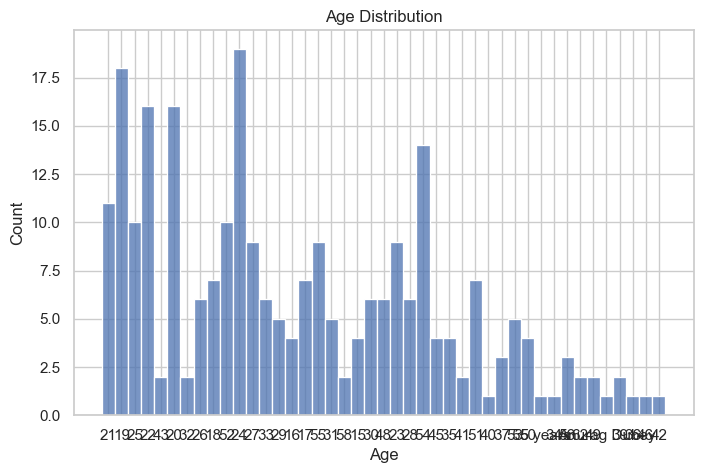

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

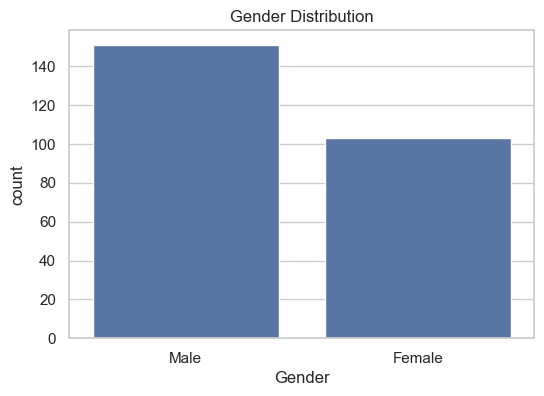

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

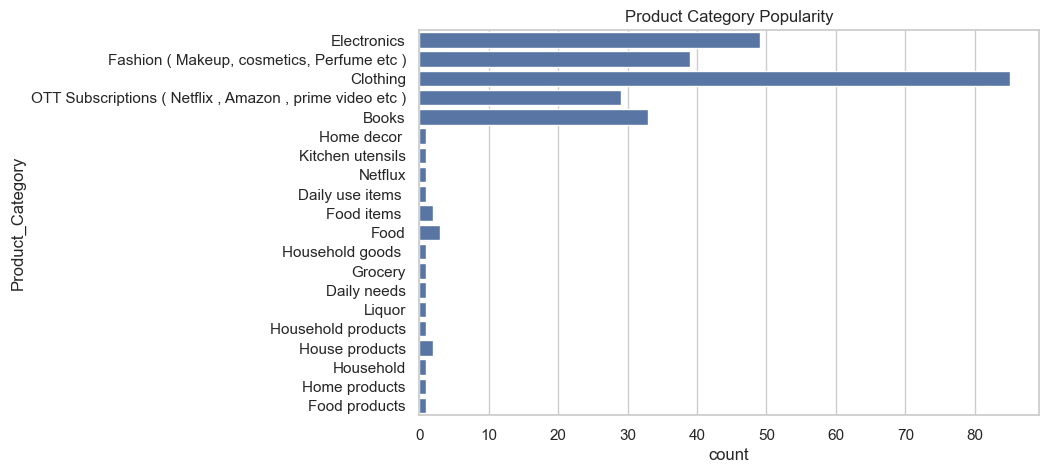

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(y="Product_Category", data=df)
plt.title("Product Category Popularity")
plt.show()

In [21]:
print(df["Product_Category"].value_counts())

Product_Category
Clothing                                                    85
Electronics                                                 49
Fashion ( Makeup, cosmetics, Perfume etc )                  39
Books                                                       33
OTT Subscriptions ( Netflix , Amazon , prime video etc )    29
Food                                                         3
Food items                                                   2
House products                                               2
Home decor                                                   1
Kitchen utensils                                             1
Netflux                                                      1
Daily use items                                              1
Household goods                                              1
Grocery                                                      1
Daily needs                                                  1
Liquor                                

In [22]:
print(df["Avg_Spend"].value_counts())

Avg_Spend
Between ₹1000-₹5000    112
Less Than ₹1000         94
Greater than ₹5000      48
Name: count, dtype: int64


In [23]:
print(df["Prefer_Cheap_Product"].value_counts())

Prefer_Cheap_Product
Yes      101
No        91
Maybe     62
Name: count, dtype: int64


In [24]:
print(df["Shopping_Frequency"].value_counts())

Shopping_Frequency
1    77
4    51
2    50
3    50
5    23
0     3
Name: count, dtype: int64


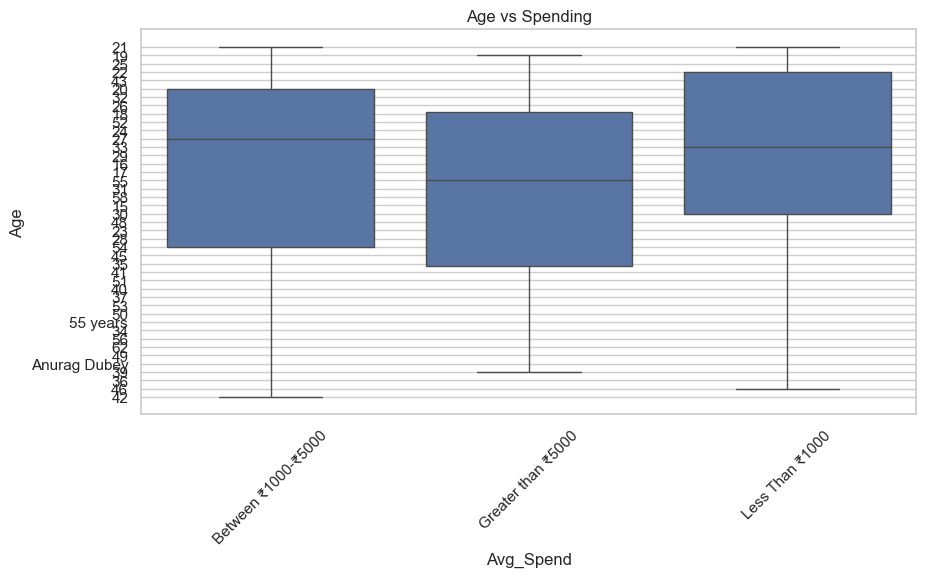

In [25]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Avg_Spend", y="Age", data=df)
plt.xticks(rotation=45)
plt.title("Age vs Spending")
plt.show()

In [26]:
cross_tab = pd.crosstab(df["Gender"], df["Product_Category"])
print(cross_tab)

Product_Category  Books  Clothing  Daily needs  Daily use items   Electronics  \
Gender                                                                          
Female               17        32            0                 0            7   
Male                 16        53            1                 1           42   

Product_Category  Fashion ( Makeup, cosmetics, Perfume etc )  Food  \
Gender                                                               
Female                                                    29     0   
Male                                                      10     3   

Product_Category  Food items   Food products  Grocery  Home decor   \
Gender                                                               
Female                      0              1        0            1   
Male                        2              0        1            0   

Product_Category  Home products  House products  Household  Household goods   \
Gender                           

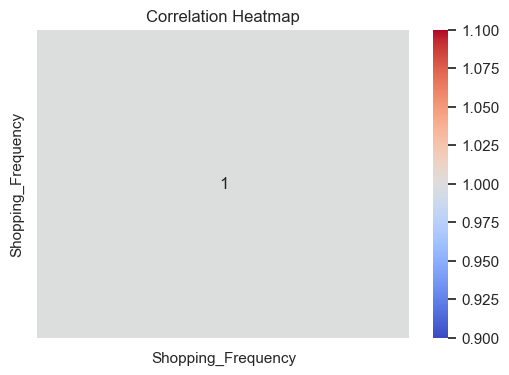

In [27]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [28]:
print("📊 Key Insights:")
print("1. Majority users are aged between 20–30")
print("2. Clothing is the most popular category")
print("3. Most users prefer branded products")
print("4. Average spending is between ₹1000–₹5000")
print("5. Users shop at a moderate frequency")

📊 Key Insights:
1. Majority users are aged between 20–30
2. Clothing is the most popular category
3. Most users prefer branded products
4. Average spending is between ₹1000–₹5000
5. Users shop at a moderate frequency
